# Figure 1

Patient & clinical demographics — missingness, OS/EFS status, AGE distribution

1.A
N = 2870 | EFS_MONTHS 28.4% (816), OS_MONTHS 27.0% (774), RACE 25.9%, ETHNICITY 14.6%, OS_STATUS 12.4%, SEX 0.5%


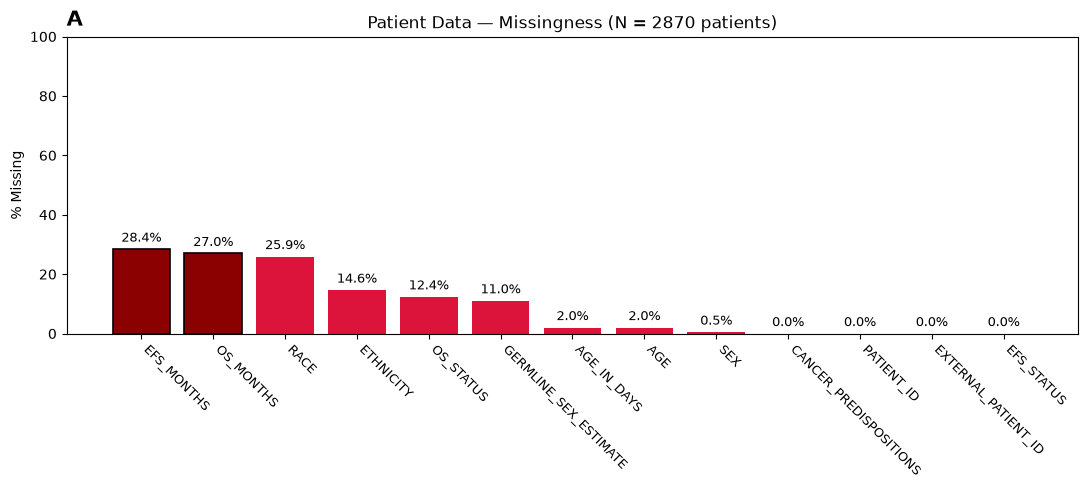

In [1]:
# Panel 1.A — Patient Data: Missingness  (context/figure_instructions/fig_patients_demographics.md)
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- data: self-contained (no cleaning needed for missingness) ---
PATIENT_FILE = "../../PBTA_RNA/data_clinical_patient_attributes.txt"
pat = pd.read_csv(PATIENT_FILE, sep="\t", header=4,
                  dtype={"AGE": float, "AGE_IN_DAYS": float,
                         "OS_MONTHS": float, "EFS_MONTHS": float})

# --- computation: % null per column, sorted descending ---
N = len(pat)
miss = pat.isna().mean().sort_values(ascending=False) * 100
nulls = pat.isna().sum().reindex(miss.index)
highlight = {"EFS_MONTHS", "OS_MONTHS"}

print("1.A")
print("N =", N, "| EFS_MONTHS {:.1f}% ({}), OS_MONTHS {:.1f}% ({}), RACE {:.1f}%, ETHNICITY {:.1f}%, OS_STATUS {:.1f}%, SEX {:.1f}%".format(
    miss["EFS_MONTHS"], int(nulls["EFS_MONTHS"]), miss["OS_MONTHS"], int(nulls["OS_MONTHS"]),
    miss["RACE"], miss["ETHNICITY"], miss["OS_STATUS"], miss["SEX"]))

# --- plot: vertical bar, crimson, EFS_MONTHS/OS_MONTHS highlighted ---
fig, ax = plt.subplots(figsize=(11, 5))
colors = ["crimson" if c not in highlight else "darkred" for c in miss.index]
edges = ["black" if c in highlight else "none" for c in miss.index]
ax.bar(range(len(miss)), miss.values, color=colors, edgecolor=edges, linewidth=1.2)
ax.set_xticks(range(len(miss)))
ax.set_xticklabels(miss.index, rotation=-45, ha="left", fontsize=9)
ax.set_ylabel("% Missing")
ax.set_ylim(0, 100)
ax.set_title(f"Patient Data — Missingness (N = {N} patients)")
for i, v in enumerate(miss.values):
    ax.text(i, v + 1.5, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
ax.text(0.0, 1.02, "A", transform=ax.transAxes, fontsize=15, fontweight="bold",
        va="bottom", ha="left")
fig.tight_layout()
plt.show()


1.B
N = 2870 | LIVING 1875 (65.3%), DECEASED 640 (22.3%), Unknown 355 (12.4%)


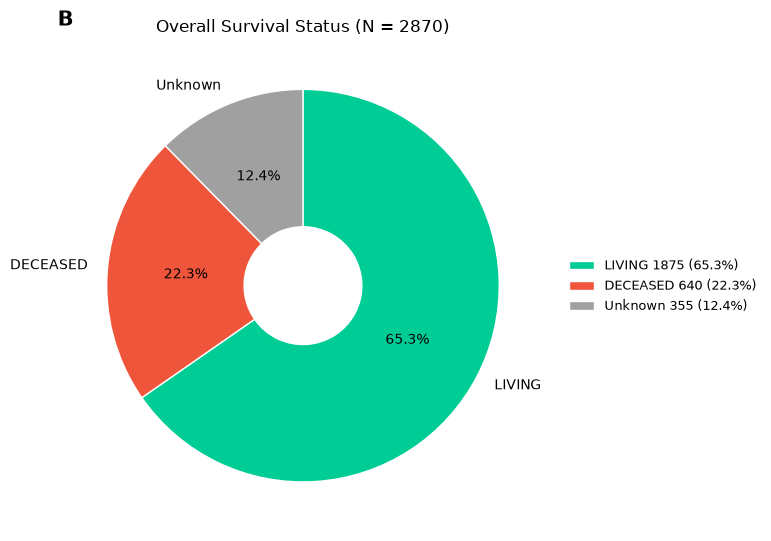

In [2]:
# Panel 1.B — Overall Survival Status  (context/figure_instructions/fig_patients_demographics.md)
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- data: self-contained + clean_os() ---
PATIENT_FILE = "../../PBTA_RNA/data_clinical_patient_attributes.txt"
pat = pd.read_csv(PATIENT_FILE, sep="\t", header=4,
                  dtype={"AGE": float, "AGE_IN_DAYS": float,
                         "OS_MONTHS": float, "EFS_MONTHS": float})
pat["OS_STATUS"] = pat["OS_STATUS"].str.strip()
pat["os_label"] = pat["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)

# --- computation: LIVING / DECEASED / Unknown (NaN -> Unknown) ---
N = len(pat)
os_c = pat["os_label"].fillna("Unknown").value_counts()
order = ["LIVING", "DECEASED", "Unknown"]
counts = [int(os_c.get(o, 0)) for o in order]
pct = [c / N * 100 for c in counts]

print("1.B")
print("N =", N, "| LIVING %d (%.1f%%), DECEASED %d (%.1f%%), Unknown %d (%.1f%%)" % (
    counts[0], pct[0], counts[1], pct[1], counts[2], pct[2]))

# --- plot: donut (hole = 0.3 radius), label + percent ---
colors = ["#00CC96", "#EF553B", "#A0A0A0"]  # green / red / gray
fig, ax = plt.subplots(figsize=(7.5, 5.5))
wedges, labels, autotexts = ax.pie(
    counts, labels=order, colors=colors, autopct="%1.1f%%",
    startangle=90, counterclock=False, wedgeprops=dict(width=0.7, edgecolor="white"))
for t in autotexts:
    t.set_fontsize(10)
ax.set_title("Overall Survival Status (N = 2870)")
ax.text(0.0, 1.02, "B", transform=ax.transAxes, fontsize=15, fontweight="bold",
        va="bottom", ha="left")
ax.legend(wedges, [f"{o} {c} ({c / N * 100:.1f}%)" for o, c in zip(order, counts)],
          loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=9)
fig.tight_layout()
plt.show()


1.C
Binary: {'No Event': 1286, 'Event': 1222, 'Unknown': 362}
Detailed: {'No Event': 1286, 'Progressive': 423, 'NA': 362, 'Recurrence': 305, 'Progressive - Metastatic': 177, 'Deceased-due to disease': 158, 'Recurrence - Metastatic': 88, 'Second Malignancy': 45, 'Deceased-due to other causes': 9, 'Deceased-causes unavailable': 6, 'Deceased-due to unknown causes': 6, 'Second Malignancy - Metastatic': 5}


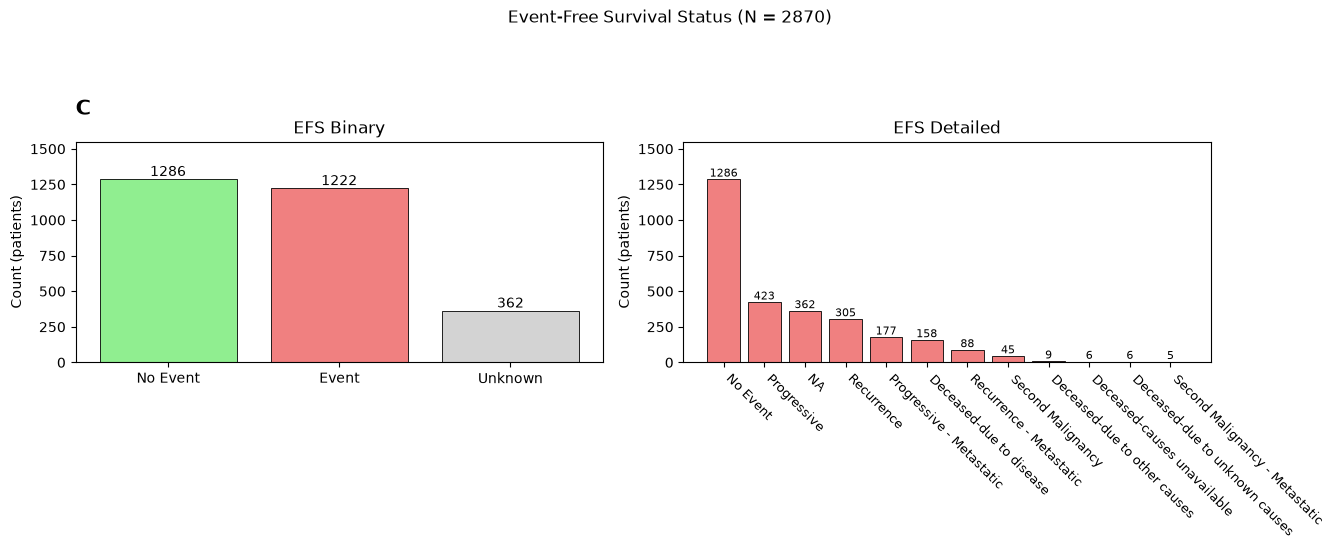

In [3]:
# Panel 1.C — Event-Free Survival Status  (context/figure_instructions/fig_patients_demographics.md)
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- data: self-contained + clean_efs() ---
PATIENT_FILE = "../../PBTA_RNA/data_clinical_patient_attributes.txt"
pat = pd.read_csv(PATIENT_FILE, sep="\t", header=4,
                  dtype={"AGE": float, "AGE_IN_DAYS": float,
                         "OS_MONTHS": float, "EFS_MONTHS": float})
pat["EFS_STATUS"] = pat["EFS_STATUS"].str.strip()
pat["efs_detail"] = pat["EFS_STATUS"].str.replace(r"^\d+:", "", regex=True)
pat["efs_event"] = pat["EFS_STATUS"].apply(
    lambda x: 0 if pd.notna(x) and x == "0:No Event"
    else (1 if pd.notna(x) and x != "1:NA" else np.nan))
pat["efs_bin"] = pat["efs_event"].map({1: "Event", 0: "No Event"}).fillna("Unknown")

# --- computation: binary (3) + detailed (12) ---
bin_order = ["No Event", "Event", "Unknown"]
bin_counts = [int(pat["efs_bin"].value_counts().get(o, 0)) for o in bin_order]
ed = pat["efs_detail"].fillna("Unknown").value_counts()
det_cats = list(ed.index)
det_counts = [int(v) for v in ed.values]

print("1.C")
print("Binary:", dict(zip(bin_order, bin_counts)))
print("Detailed:", dict(zip(det_cats, det_counts)))

# --- plot: two grouped bars side-by-side ---
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.5))
ax = axes[0]
b = ax.bar(bin_order, bin_counts, color=["lightgreen", "lightcoral", "lightgray"],
           edgecolor="black", linewidth=0.6)
ax.bar_label(b, label_type="edge", fontsize=10)
ax.set_ylabel("Count (patients)")
ax.set_title("EFS Binary")
ax.set_ylim(0, 1550)
ax.text(0.0, 1.10, "C", transform=ax.transAxes, fontsize=15, fontweight="bold",
        va="bottom", ha="left")

ax = axes[1]
b = ax.bar(det_cats, det_counts, color="lightcoral", edgecolor="black", linewidth=0.6)
ax.bar_label(b, label_type="edge", fontsize=8)
ax.set_xticks(range(len(det_cats)))
ax.set_xticklabels(det_cats, rotation=-45, ha="left", fontsize=9)
ax.set_ylabel("Count (patients)")
ax.set_title("EFS Detailed")
ax.set_ylim(0, 1550)

fig.suptitle("Event-Free Survival Status (N = 2870)", y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


1.D
n = 2812 (of 2870) | mean 9.4, median 8.0, min 0.0, max 73.0 | missing 58 (2.0%) | Tukey IQR outliers (>27.125 yr): 62


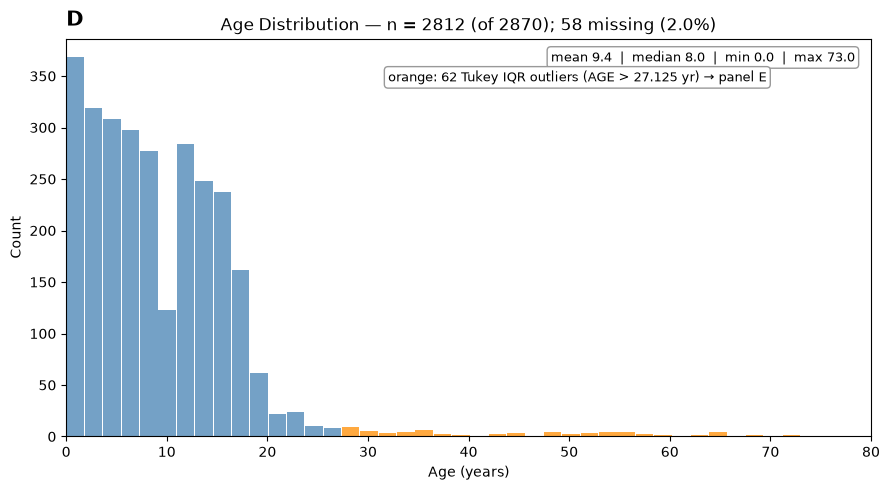

In [4]:
# Panel 1.D — Age Distribution  (context/figure_instructions/fig_patients_demographics.md)
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- data: self-contained ---
PATIENT_FILE = "../../PBTA_RNA/data_clinical_patient_attributes.txt"
pat = pd.read_csv(PATIENT_FILE, sep="\t", header=4,
                  dtype={"AGE": float, "AGE_IN_DAYS": float,
                         "OS_MONTHS": float, "EFS_MONTHS": float})

# --- computation: AGE stats (drop NaN) ---
N = len(pat)
age = pat["AGE"].dropna()
n_miss = int(pat["AGE"].isna().sum())
q1, q3 = age.quantile(0.25), age.quantile(0.75)
thresh = q3 + 1.5 * (q3 - q1)      # 27.125
n_out = int((age > thresh).sum())  # 62

print("1.D")
print("n = %d (of %d) | mean %.1f, median %.1f, min %.1f, max %.1f | missing %d (%.1f%%) | Tukey IQR outliers (>%.3f yr): %d" % (
    len(age), N, age.mean(), age.median(), age.min(), age.max(), n_miss, n_miss / N * 100, thresh, n_out))

# --- plot: histogram, 40 bins, steelblue, only Tukey outlier tail highlighted ---
fig, ax = plt.subplots(figsize=(9, 5))
n, bins, patches = ax.hist(age, bins=40, color="steelblue", alpha=0.75, rwidth=0.95)
for p, left in zip(patches, bins[:-1]):
    if left >= thresh:
        p.set_facecolor("#FF8C00")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Count")
ax.set_xlim(0, 80)
ax.set_title("Age Distribution — n = 2812 (of 2870); 58 missing (2.0%)")
stats_txt = "mean 9.4  |  median 8.0  |  min 0.0  |  max 73.0"
ax.text(0.98, 0.97, stats_txt, transform=ax.transAxes, ha="right", va="top",
        fontsize=9, bbox=dict(boxstyle="round", fc="white", ec="0.6"))
ax.text(0.40, 0.92, "orange: %d Tukey IQR outliers (AGE > %.3f yr) → panel E" % (n_out, thresh),
        transform=ax.transAxes, ha="left", va="top", fontsize=9,
        bbox=dict(boxstyle="round", fc="white", ec="0.6"))
ax.text(0.0, 1.02, "D", transform=ax.transAxes, fontsize=15, fontweight="bold",
        va="bottom", ha="left")
fig.tight_layout()
plt.show()


1.E
Q1 4.00, Q3 13.25, IQR 9.25 → Tukey threshold AGE > 27.125 yr
outlier patients: 62 (of 2812 with AGE, range 28–73); Oligodendroglioma 53/62 (85.5%)
{'Oligodendroglioma': 53, 'High-grade glioma': 3, 'Neurofibroma/Plexiform': 1, 'Schwannoma': 1, 'Low-grade glioma': 1, 'Diffuse midline glioma': 1, 'Meningioma': 1, 'Medulloblastoma': 1}


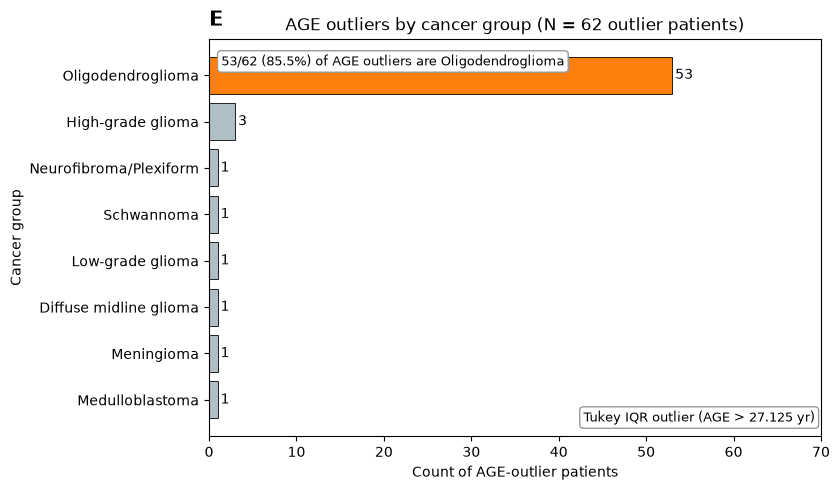

In [5]:
# Panel 1.E — AGE outliers by cancer group  (context/figure_instructions/fig_patients_demographics.md)
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- data: self-contained; merge patient + sample tables on PATIENT_ID ---
PATIENT_FILE = "../../PBTA_RNA/data_clinical_patient_attributes.txt"
SAMPLE_FILE = "../../PBTA_RNA/data_clinical_sample_attributes.txt"
pat = pd.read_csv(PATIENT_FILE, sep="\t", header=4, dtype={"AGE": float})
samp = pd.read_csv(SAMPLE_FILE, sep="\t", header=4)

# --- computation: Tukey IQR outliers (AGE > Q3 + 1.5*IQR); any-sample Oligodendroglioma rule ---
age = pat["AGE"].dropna()
q1, q3 = age.quantile(0.25), age.quantile(0.75)
thresh = q3 + 1.5 * (q3 - q1)  # 27.125
out = pat[pat["AGE"] > thresh].copy()
m = out.merge(samp[["PATIENT_ID", "CANCER_GROUP"]], on="PATIENT_ID", how="left")
grp = m.groupby("PATIENT_ID")["CANCER_GROUP"].apply(
    lambda s: "Oligodendroglioma" if (s == "Oligodendroglioma").any()
    else (s.dropna().iloc[0] if s.dropna().shape[0] else "NA"))
cnt = grp.value_counts().sort_values(ascending=False)
n_out = len(grp)
oligo = int(cnt.get("Oligodendroglioma", 0))

print("1.E")
print("Q1 %.2f, Q3 %.2f, IQR %.2f → Tukey threshold AGE > %.3f yr" % (q1, q3, q3 - q1, thresh))
print("outlier patients: %d (of %d with AGE, range %d–%d); Oligodendroglioma %d/%d (%.1f%%)" % (
    n_out, len(age), out["AGE"].min(), out["AGE"].max(), oligo, n_out, oligo / n_out * 100))
print({k: int(v) for k, v in cnt.items()})

# --- plot: horizontal count bar per cancer group (>=1 outlier), Oligodendroglioma highlighted ---
fig, ax = plt.subplots(figsize=(8.5, 5))
colors = ["#FF7F0E" if g == "Oligodendroglioma" else "#B0BEC5" for g in cnt.index]
b = ax.barh(cnt.index, cnt.values, color=colors, edgecolor="black", linewidth=0.6)
ax.bar_label(b, label_type="edge", padding=2, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("Count of AGE-outlier patients")
ax.set_ylabel("Cancer group")
ax.set_title("AGE outliers by cancer group (N = 62 outlier patients)")
ax.set_xlim(0, 70)
ax.text(0.0, 1.02, "E", transform=ax.transAxes, fontsize=15, fontweight="bold",
        va="bottom", ha="left")
ax.text(0.02, 0.96, "53/62 (85.5%) of AGE outliers are Oligodendroglioma",
        transform=ax.transAxes, fontsize=9, ha="left", va="top",
        bbox=dict(boxstyle="round", fc="white", ec="0.6"))
ax.text(0.99, 0.03, "Tukey IQR outlier (AGE > 27.125 yr)",
        transform=ax.transAxes, fontsize=9, ha="right", va="bottom",
        bbox=dict(boxstyle="round", fc="white", ec="0.6"))
fig.tight_layout()
plt.show()
